In [ ]:
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo
import pandas as pd

dataset = fetch_ucirepo(id=544)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
# Toutes les infos d'un coup !
import pandas as pd

print("=== TAILLE DU DATASET ===")
print(df.shape)

print("\n=== TYPES DES COLONNES ===")
print(df.dtypes)

print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())

print("\n=== DISTRIBUTION DES CLASSES ===")
print(df['NObeyesdad'].value_counts())
print("\nEn pourcentage :")
print(df['NObeyesdad'].value_counts(normalize=True).mul(100).round(1))

=== TAILLE DU DATASET ===
(2111, 17)

=== TYPES DES COLONNES ===
Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

=== VALEURS MANQUANTES ===
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0

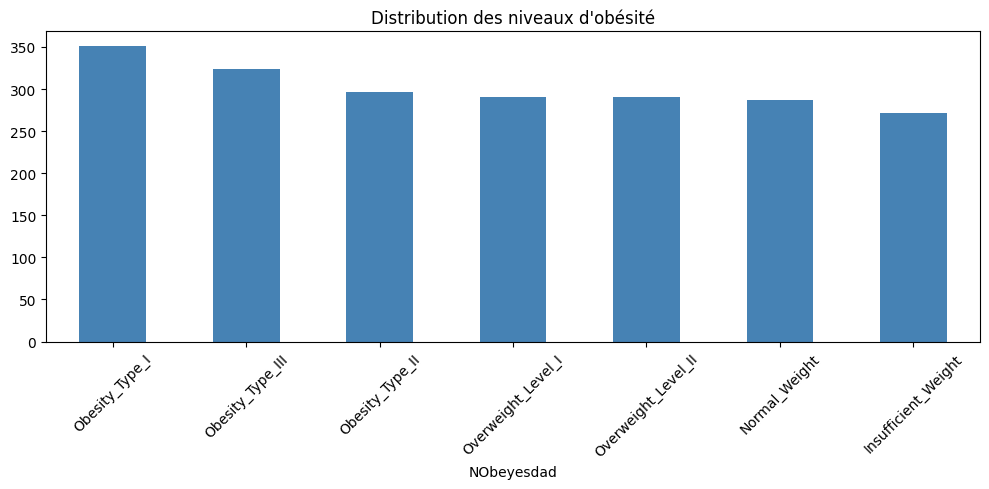

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution des classes
df['NObeyesdad'].value_counts().plot(kind='bar', color='steelblue', figsize=(10,5))
plt.title("Distribution des niveaux d'obésité")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

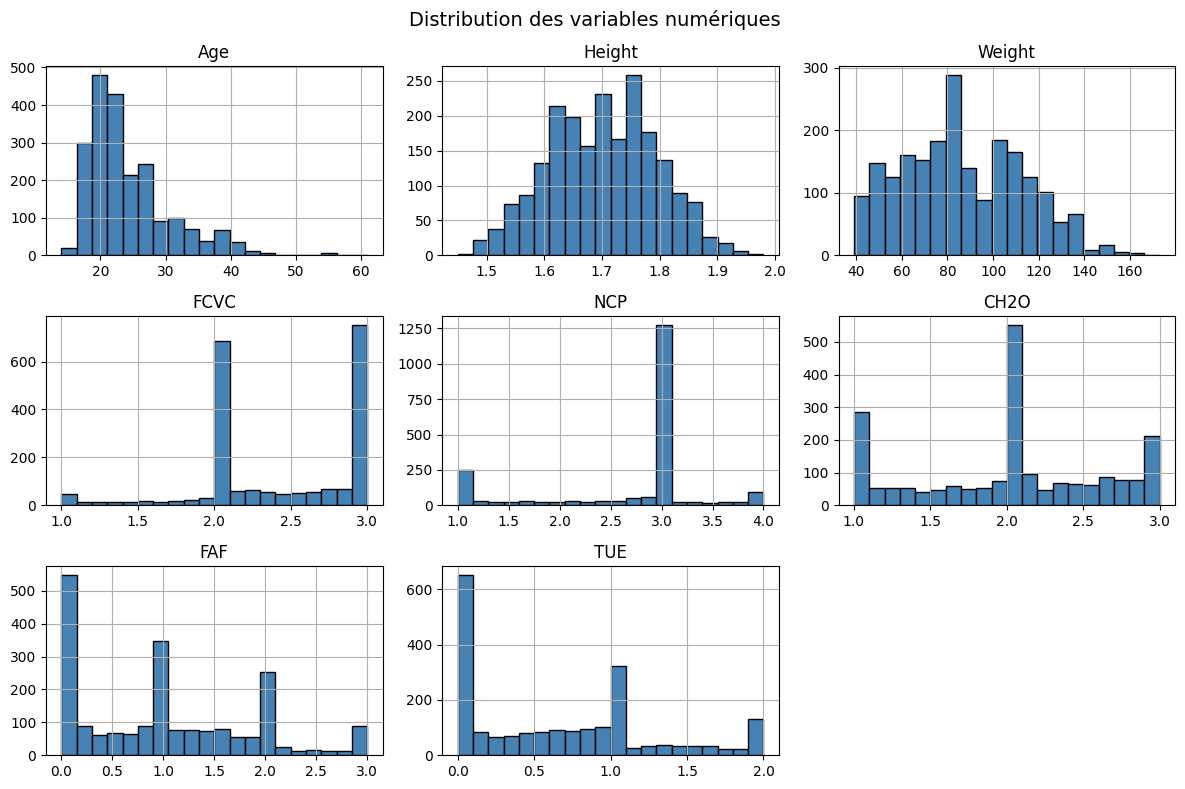

In [ ]:
# Distribution des variables numériques
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

df[num_cols].hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle("Distribution des variables numériques", fontsize=14)
plt.tight_layout()
plt.show()

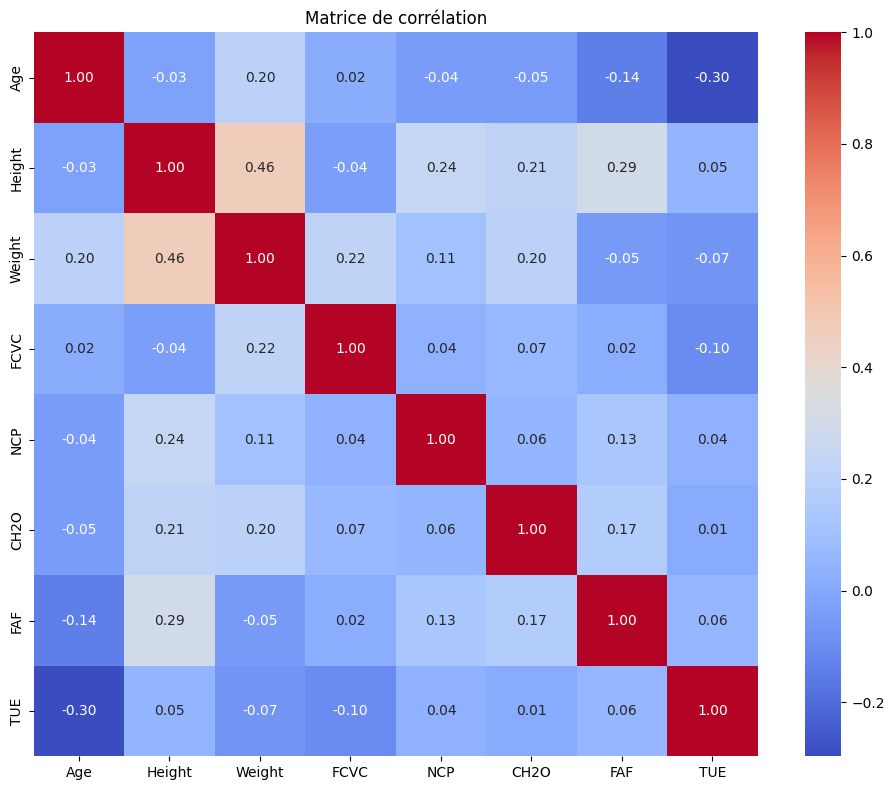

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC',
            'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Encoder aussi la cible
df_encoded['NObeyesdad'] = le.fit_transform(df_encoded['NObeyesdad'])

df_encoded.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22.0,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC',
            'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded['NObeyesdad'] = le.fit_transform(df_encoded['NObeyesdad'])

df_encoded.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22.0,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6


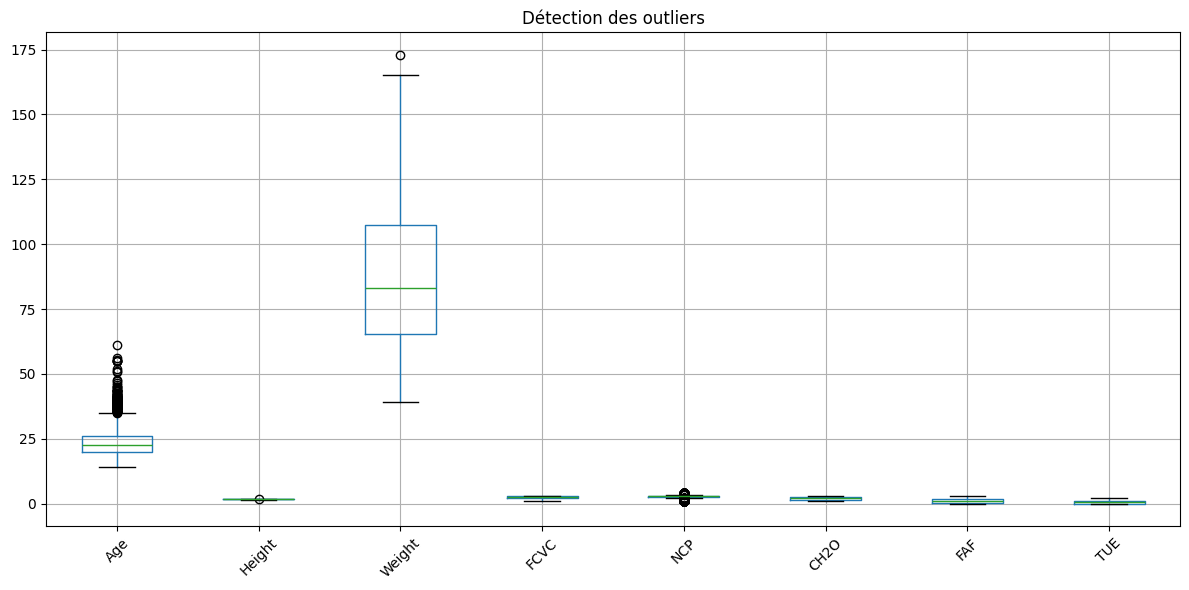

In [ ]:
import matplotlib.pyplot as plt

num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

plt.figure(figsize=(12, 6))
df[num_cols].boxplot()
plt.title("Détection des outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

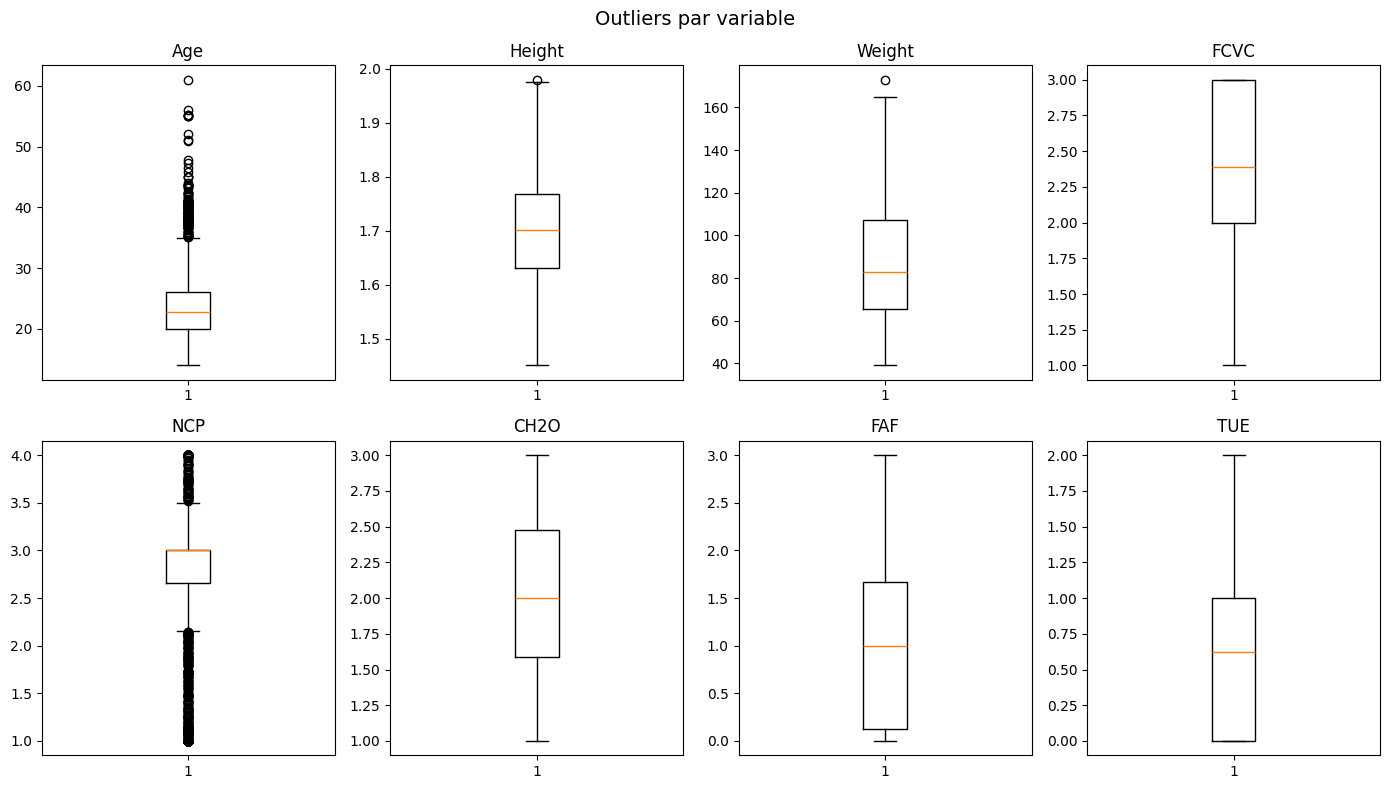

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.suptitle("Outliers par variable", fontsize=14)
plt.tight_layout()
plt.show()